In [34]:

!pip -q install timm

import os, sys, math, random, time, itertools
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import timm

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit

# Reproducibility
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
set_seed(42)

# Device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device, "| CUDA available:", torch.cuda.is_available())


Using device: cuda | CUDA available: True


In [35]:

!mkdir -p /content/data
!wget -q https://download.pytorch.org/tutorial/hymenoptera_data.zip -O /content/data/hymenoptera_data.zip
!unzip -q /content/data/hymenoptera_data.zip -d /content/data/

# Point DATA_DIR to it
DATA_DIR = "/content/data/hymenoptera_data"

!mkdir -p "/content/data/hymenoptera_data/test"
!cp -r "/content/data/hymenoptera_data/val/"* "/content/data/hymenoptera_data/test/"


replace /content/data/hymenoptera_data/train/ants/0013035.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [36]:

if device.type != "cuda":
    print("NOTE: GPU not detected. In Colab, go to Runtime > Change runtime type > Hardware accelerator: GPU.")
else:
    print(torch.cuda.get_device_name(0))


Tesla T4


In [37]:

import os
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedShuffleSplit

IMG_SIZE = 224
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])
test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_dir = os.path.join(DATA_DIR, "train")
val_dir   = os.path.join(DATA_DIR, "val")
test_dir  = os.path.join(DATA_DIR, "test")

def make_loaders_from_subfolders(batch_size=32, num_workers=2):
    """Use existing train/val/test subfolders."""
    train_ds = datasets.ImageFolder(train_dir, transform=train_tfms)
    val_ds   = datasets.ImageFolder(val_dir,   transform=test_tfms)
    test_ds  = datasets.ImageFolder(test_dir,  transform=test_tfms)
    class_names = train_ds.classes
    loaders = {
        "train": DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True),
        "val":   DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True),
        "test":  DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True),
    }
    return loaders, class_names, train_ds, val_ds, test_ds


if os.path.isdir(train_dir) and os.path.isdir(val_dir) and os.path.isdir(test_dir):
    loaders, class_names, train_ds, val_ds, test_ds = make_loaders_from_subfolders()
    print("Loaded dataset from existing train/val/test subfolders.")

num_classes = len(class_names)
print("Classes:", class_names)
print("Counts -> train:", len(train_ds), "| val:", len(val_ds), "| test:", len(test_ds))


Loaded dataset from existing train/val/test subfolders.
Classes: ['ants', 'bees']
Counts -> train: 244 | val: 153 | test: 153


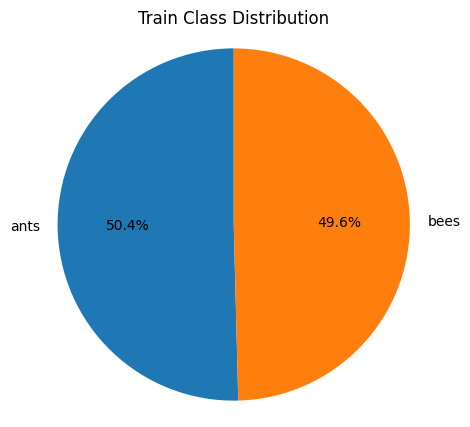

Train counts per class: {'ants': np.int64(123), 'bees': np.int64(121)}


In [38]:

train_targets = np.array(train_ds.targets)
counts = [(train_targets == i).sum() for i in range(num_classes)]

plt.figure(figsize=(5,5))
plt.pie(counts, labels=class_names, autopct='%1.1f%%', startangle=90)
plt.title("Train Class Distribution")
plt.axis('equal'); plt.show()

print("Train counts per class:", dict(zip(class_names, counts)))


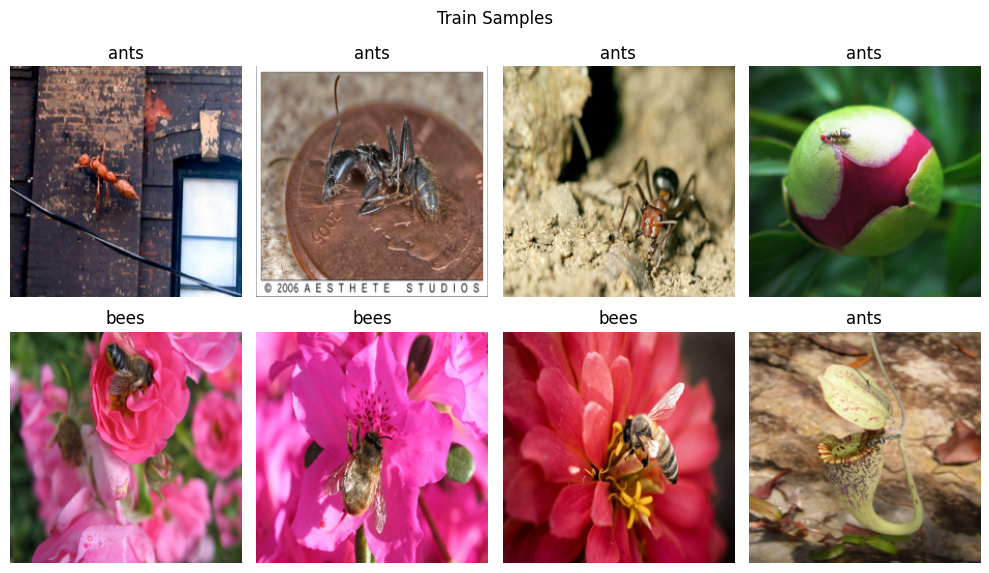

In [39]:

inv_mean = torch.tensor(mean).view(3,1,1)
inv_std  = torch.tensor(std).view(3,1,1)

def denorm(x):
    return x * inv_std + inv_mean

batch = next(iter(loaders["train"]))
images, labels = batch
fig, axes = plt.subplots(2, 4, figsize=(10,6))
for ax, img, lab in zip(axes.flatten(), images[:8], labels[:8]):
    ax.imshow(denorm(img).permute(1,2,0).clamp(0,1))
    ax.set_title(class_names[lab.item()])
    ax.axis('off')
plt.suptitle("Train Samples")
plt.tight_layout()
plt.show()


In [40]:

model = timm.create_model('resnet18', pretrained=True, num_classes=num_classes)
model = model.to(device)
for p in model.parameters():
    p.requires_grad = False

clf = model.get_classifier()
if clf is None:
    raise RuntimeError("Could not find classifier head; check your model arch.")

for p in clf.parameters():
    p.requires_grad = True

def set_bn_eval_for_frozen(mod):
    for m in mod.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.SyncBatchNorm)):
            any_trainable = any(p.requires_grad for p in m.parameters())
            if not any_trainable:
                m.eval()


criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

print("Model ready. Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))


Model ready. Trainable params: 1026


In [41]:

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    set_bn_eval_for_frozen(model)
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labs in loader:
        imgs, labs = imgs.to(device), labs.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labs)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labs).sum().item()
        total += labs.size(0)
    return running_loss/total, correct/total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labs in loader:
        imgs, labs = imgs.to(device), labs.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labs)
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labs).sum().item()
        total += labs.size(0)
    return running_loss/total, correct/total

EPOCHS = 10  # adjust as needed
history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
best_val_acc, best_state = 0.0, None

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = train_one_epoch(model, loaders["train"], optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, loaders["val"], criterion, device)
    scheduler.step()

    history["train_loss"].append(tr_loss); history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

# Load best weights
if best_state is not None:
    model.load_state_dict({k:v.to(device) for k,v in best_state.items()})
    print(f"Loaded best model (val acc = {best_val_acc:.4f})")


Epoch 01/10 | Train Loss: 0.6408 Acc: 0.6721 | Val Loss: 0.5782 Acc: 0.8627
Epoch 02/10 | Train Loss: 0.5354 Acc: 0.9016 | Val Loss: 0.5002 Acc: 0.8824
Epoch 03/10 | Train Loss: 0.4588 Acc: 0.9344 | Val Loss: 0.4517 Acc: 0.8824
Epoch 04/10 | Train Loss: 0.4083 Acc: 0.9221 | Val Loss: 0.4176 Acc: 0.8889
Epoch 05/10 | Train Loss: 0.3656 Acc: 0.9344 | Val Loss: 0.3884 Acc: 0.8954
Epoch 06/10 | Train Loss: 0.3461 Acc: 0.9262 | Val Loss: 0.3718 Acc: 0.9085
Epoch 07/10 | Train Loss: 0.3256 Acc: 0.9344 | Val Loss: 0.3615 Acc: 0.9150
Epoch 08/10 | Train Loss: 0.3125 Acc: 0.9262 | Val Loss: 0.3558 Acc: 0.9150
Epoch 09/10 | Train Loss: 0.3106 Acc: 0.9303 | Val Loss: 0.3537 Acc: 0.9150
Epoch 10/10 | Train Loss: 0.3091 Acc: 0.9385 | Val Loss: 0.3531 Acc: 0.9150
Loaded best model (val acc = 0.9150)


In [42]:

test_loss, test_acc = evaluate(model, loaders["test"], criterion, device)
print(f"TEST -> Loss: {test_loss:.4f} | Acc: {test_acc:.4f}")


TEST -> Loss: 0.3615 | Acc: 0.9150


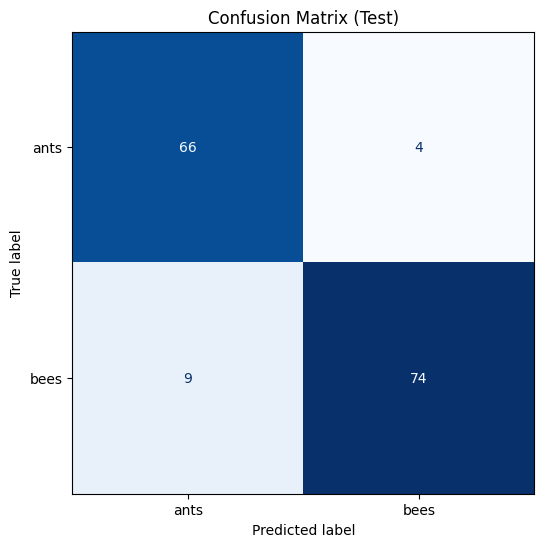

In [43]:

@torch.no_grad()
def get_all_preds_labels(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for imgs, labs in loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(list(preds))
        all_labels.extend(list(labs.numpy()))
    return np.array(all_preds), np.array(all_labels)

preds, labels = get_all_preds_labels(model, loaders["test"], device)
cm = confusion_matrix(labels, preds, labels=list(range(num_classes)))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (Test)")
plt.show()


In [44]:

overall_acc = accuracy_score(labels, preds)
print("Overall Test Accuracy:", f"{overall_acc*100:.2f}%")


Overall Test Accuracy: 91.50%


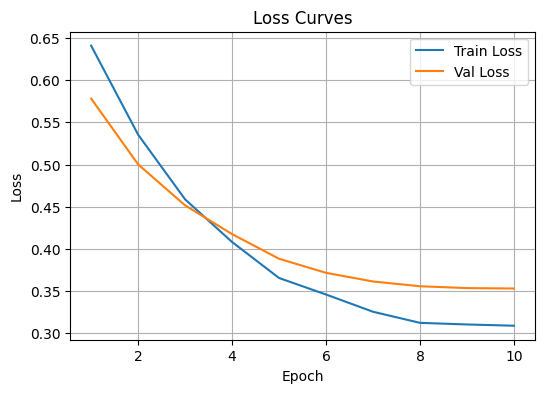

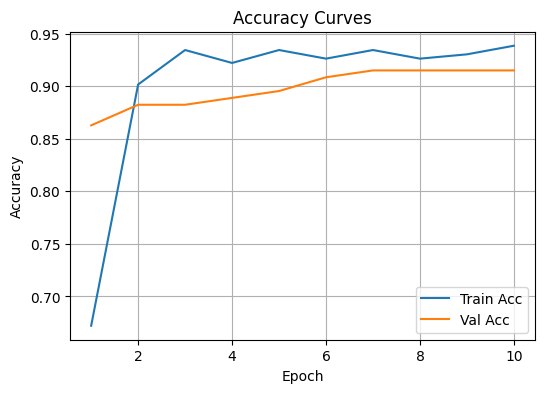

In [45]:

epochs = range(1, len(history["train_loss"])+1)

plt.figure(figsize=(6,4))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"],   label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss Curves")
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"],   label="Val Acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy Curves")
plt.legend(); plt.grid(True); plt.show()
